# Bangla Sports Sentiment Analysis
## Fine-tuned RoBERTa Model for Bengali Text Classification

**Thesis Project** — Binary Sentiment Classification (Positive / Negative)  
Dataset: Bangla Sports Sentiment Analysis Dataset (82,611 comments)

### Pipeline:
1. Data Loading & Exploration (EDA)
2. Data Preprocessing & Visualization
3. Model Training — Fine-tuned XLM-RoBERTa (multilingual, Bangla-capable)
4. Evaluation — Accuracy, Precision, Recall, F1, Confusion Matrix, ROC Curve
5. Training Curves & All Thesis Graphs

## 1. Install Dependencies

In [1]:
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn openpyxl wordcloud tqdm -q

## 2. Import Libraries

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)

from wordcloud import WordCloud
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Set style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('Set2')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}')

Device: cuda
GPU: Tesla T4


## 3. Upload & Load Dataset

In [3]:
# ── Upload from local machine (Colab) ──────────────────────────────────────
from google.colab import files
print('Please upload: Bangla_Sports_Sentiment_Analysis_Dataset.xlsx')
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Please upload: Bangla_Sports_Sentiment_Analysis_Dataset.xlsx


Saving Bangla_Sports_Sentiment_Analysis_Dataset.xlsx to Bangla_Sports_Sentiment_Analysis_Dataset.xlsx


In [4]:
df = pd.read_excel(filename)
df.columns = df.columns.str.strip()  # Remove trailing spaces

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (82611, 3)
Columns: ['Comment', 'Category', 'Cleaned_Text']


,Comment,Category,Cleaned_Text
0,মনে হয় পাড়া-মহল্লার খেলা দেখছি।,Positive,মন হয় পাড়া মহল্ল খেলা দেখ
1,বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে,Positive,বাংলাদেশ ফুটবল খালা কুত কুত খেললে
2,বাংলাদেশের দামরা ছেলে গুলো কি খেলছে,Positive,বাংলাদেশ দাম ছালা খেল
3,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতেই পারেনা,Positive,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা
4,"খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...",Positive,খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন য...


## 4. Exploratory Data Analysis (EDA)

In [5]:
print('=== Dataset Info ===')
df.info()
print('\n=== Null Values ===')
print(df.isnull().sum())
print('\n=== Class Distribution ===')
print(df['Category'].value_counts())
print(f'\nClass balance: {df["Category"].value_counts(normalize=True).round(3).to_dict()}')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82611 entries, 0 to 82610
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Comment       82606 non-null  object
 1   Category      82611 non-null  object
 2   Cleaned_Text  82270 non-null  object
dtypes: object(3)
memory usage: 1.9+ MB

=== Null Values ===
Comment           5
Category          0
Cleaned_Text    341
dtype: int64

=== Class Distribution ===
Category
Negative    41355
Positive    41256
Name: count, dtype: int64

Class balance: {'Negative': 0.501, 'Positive': 0.499}


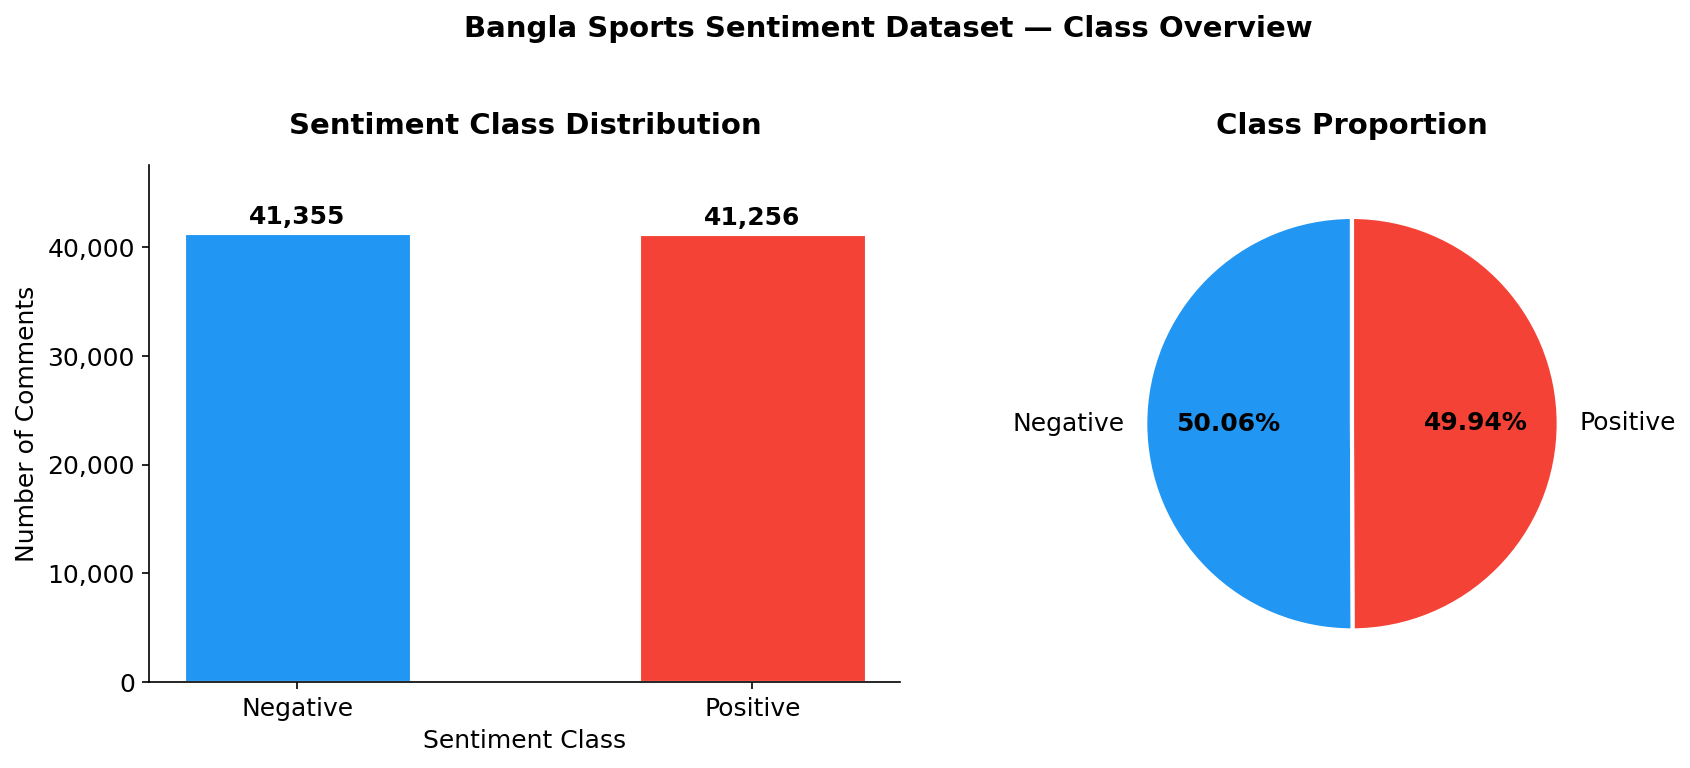

In [6]:
# ── Figure 1: Class Distribution Bar Chart ─────────────────────────────────
counts = df['Category'].value_counts()
colors = ['#2196F3', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Sentiment Class Distribution', fontweight='bold', pad=15)
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Number of Comments')
axes[0].set_ylim(0, max(counts.values) * 1.15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, autopct='%1.2f%%',
    colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Class Proportion', fontweight='bold', pad=15)

plt.suptitle('Bangla Sports Sentiment Dataset — Class Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

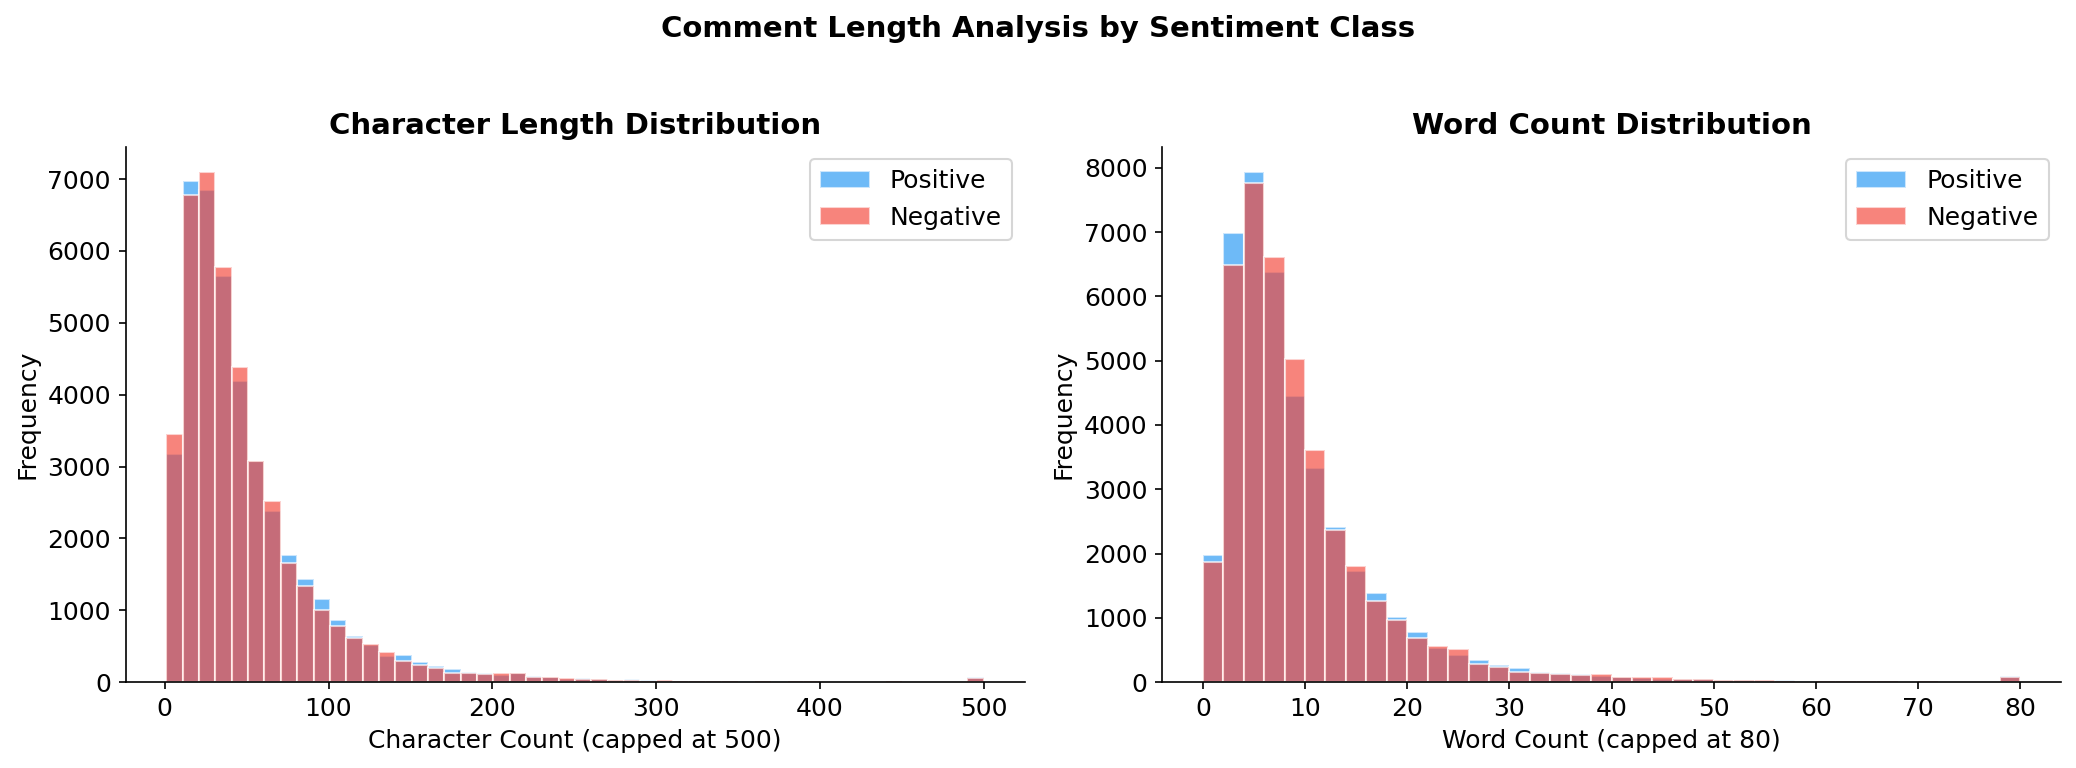


Character Length Stats:
            count  mean   std  min   25%   50%   75%     max
Category                                                    
Negative  41355.0  50.6  54.9  1.0  21.0  36.0  62.0  2113.0
Positive  41256.0  52.2  57.5  1.0  21.0  37.0  64.0  1887.0

Word Count Stats:
            count  mean  std  min  25%  50%   75%    max
Category                                                
Negative  41355.0   9.3  9.5  0.0  4.0  7.0  11.0  343.0
Positive  41256.0   9.2  9.9  0.0  4.0  7.0  11.0  305.0


In [7]:
# ── Figure 2: Comment Length Distribution ──────────────────────────────────
df['comment_len'] = df['Comment'].astype(str).apply(len)
df['word_count'] = df['Comment'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in zip(['Positive', 'Negative'], colors):
    subset = df[df['Category'] == label]
    axes[0].hist(subset['comment_len'].clip(upper=500), bins=50, alpha=0.65,
                 label=label, color=color, edgecolor='white')
    axes[1].hist(subset['word_count'].clip(upper=80), bins=40, alpha=0.65,
                 label=label, color=color, edgecolor='white')

axes[0].set_title('Character Length Distribution', fontweight='bold')
axes[0].set_xlabel('Character Count (capped at 500)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count (capped at 80)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Comment Length Analysis by Sentiment Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_length_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nCharacter Length Stats:')
print(df.groupby('Category')['comment_len'].describe().round(1))
print('\nWord Count Stats:')
print(df.groupby('Category')['word_count'].describe().round(1))

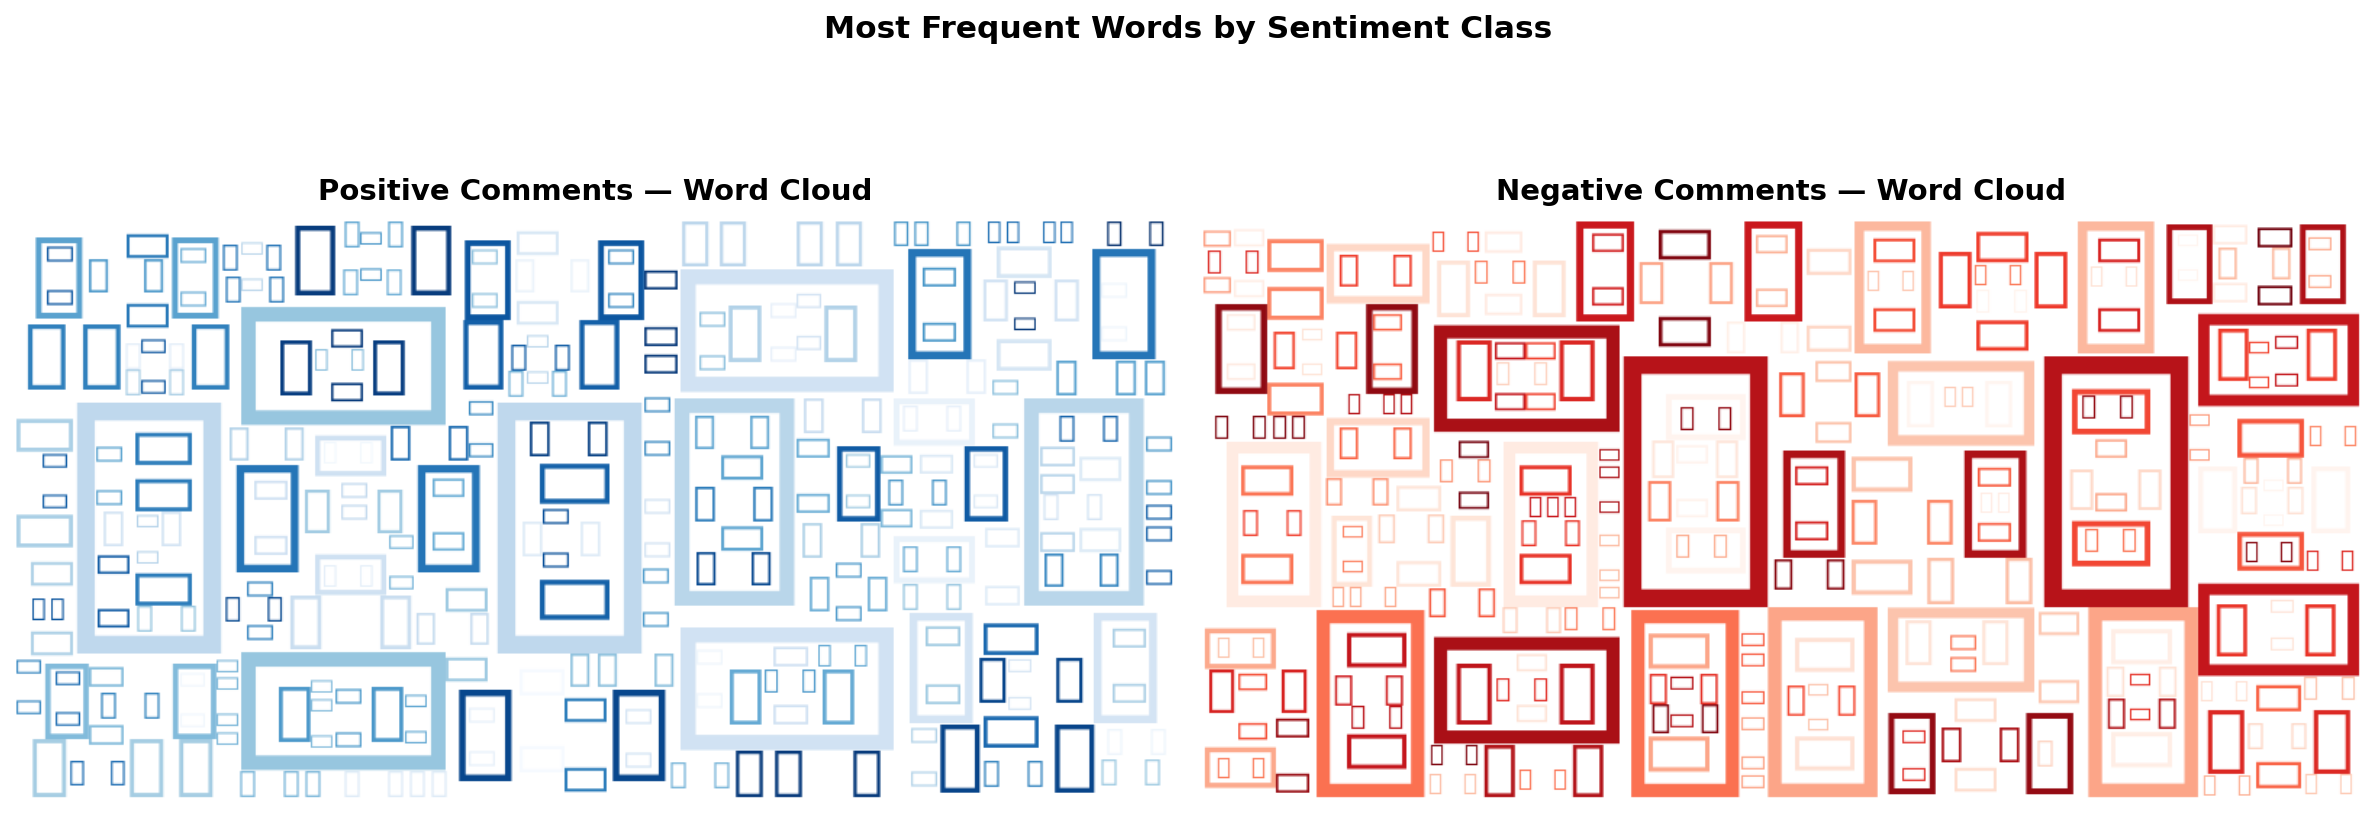

In [8]:
# ── Figure 3: Word Clouds ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, color in zip(axes, ['Positive', 'Negative'], ['Blues', 'Reds']):
    text = ' '.join(df[df['Category'] == label]['Cleaned_Text'].dropna().astype(str))
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=color,
        max_words=150,
        font_path=None,   # Colab Bengali font
        prefer_horizontal=0.7
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label} Comments — Word Cloud', fontweight='bold', fontsize=14, pad=10)

plt.suptitle('Most Frequent Words by Sentiment Class', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_wordclouds.png', bbox_inches='tight', dpi=150)
plt.show()

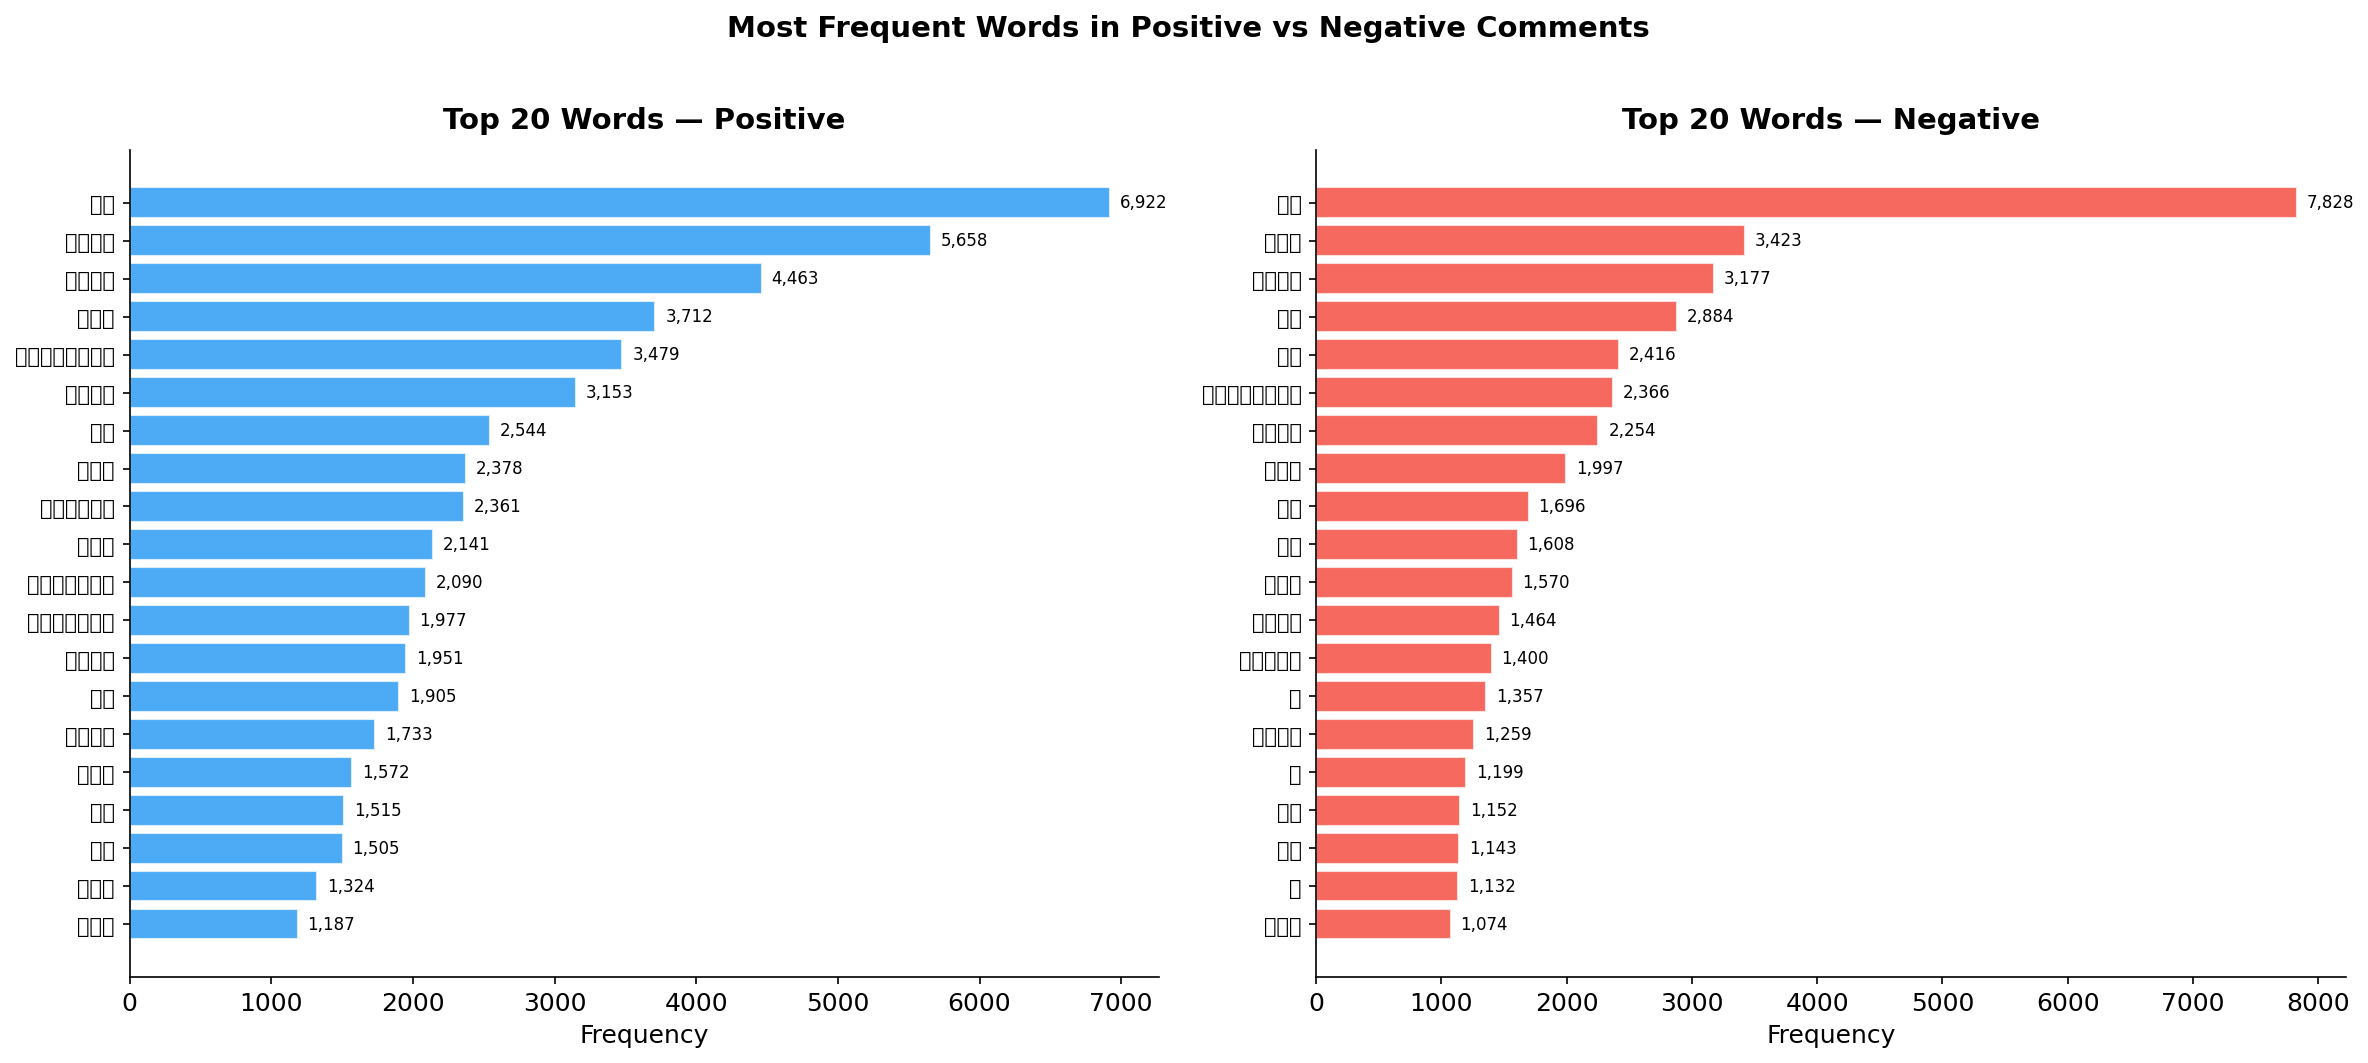

In [9]:
# ── Figure 4: Top N Most Frequent Words per Class ─────────────────────────
def top_words(series, n=20):
    words = ' '.join(series.dropna().astype(str)).split()
    return Counter(words).most_common(n)

top_pos = top_words(df[df['Category'] == 'Positive']['Cleaned_Text'])
top_neg = top_words(df[df['Category'] == 'Negative']['Cleaned_Text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, color, label in zip(
    axes,
    [top_pos, top_neg],
    ['#2196F3', '#F44336'],
    ['Positive', 'Negative']
):
    words, freqs = zip(*data)
    y_pos = range(len(words))
    bars = ax.barh(y_pos, freqs, color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Frequency')
    ax.set_title(f'Top 20 Words — {label}', fontweight='bold', pad=10)
    for bar, freq in zip(bars, freqs):
        ax.text(bar.get_width() + max(freqs)*0.01, bar.get_y() + bar.get_height()/2,
                f'{freq:,}', va='center', fontsize=8)

plt.suptitle('Most Frequent Words in Positive vs Negative Comments', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_top_words.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Data Preprocessing & Splitting

In [10]:
# Drop nulls, encode labels
df_clean = df[['Comment', 'Category']].dropna().copy()
df_clean['Comment'] = df_clean['Comment'].astype(str).str.strip()
df_clean = df_clean[df_clean['Comment'].str.len() > 0]

label_map = {'Positive': 1, 'Negative': 0}
df_clean['label'] = df_clean['Category'].map(label_map)

# 70% train | 15% val | 15% test
X = df_clean['Comment'].values
y = df_clean['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Training samples  : {len(X_train):,}')
print(f'Validation samples: {len(X_val):,}')
print(f'Test samples      : {len(X_test):,}')
print(f'Total             : {len(X):,}')

Training samples  : 57,816
Validation samples: 12,389
Test samples      : 12,390
Total             : 82,595


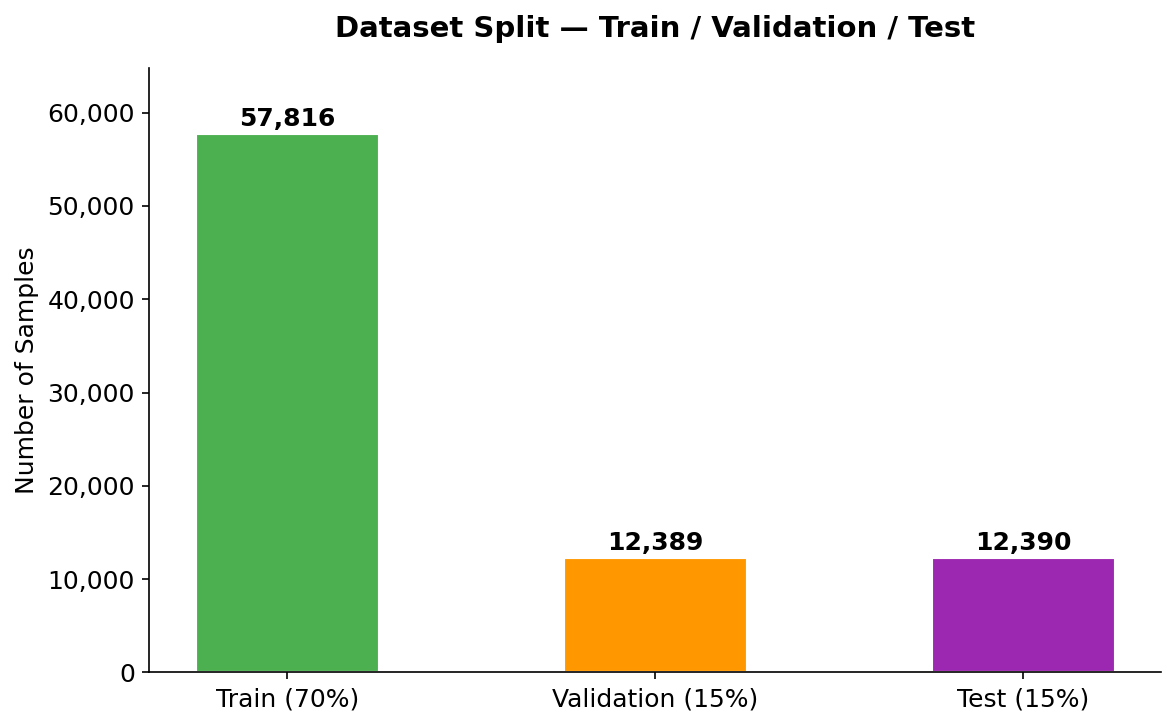

In [11]:
# ── Figure 5: Train / Val / Test Split Visualization ──────────────────────
split_labels = ['Train (70%)', 'Validation (15%)', 'Test (15%)']
split_sizes  = [len(X_train), len(X_val), len(X_test)]
split_colors = ['#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(split_labels, split_sizes, color=split_colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, split_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Dataset Split — Train / Validation / Test', fontweight='bold', pad=15)
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, max(split_sizes) * 1.12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('fig5_data_split.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Tokenization — XLM-RoBERTa

We use **`xlm-roberta-base`** — a multilingual RoBERTa model trained on 100 languages including Bengali. This is the correct Bangla-capable equivalent of the cardiffnlp twitter-roberta used in the FIFA notebook.

In [12]:
MODEL_NAME = 'xlm-roberta-base'
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 3
LR         = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')

# Quick sanity check
sample = tokenizer('বাংলাদেশ ক্রিকেট দল অসাধারণ খেলেছে', return_tensors='pt', truncation=True, padding=True)
print(f'Sample token ids shape: {sample["input_ids"].shape}')

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: xlm-roberta-base
Sample token ids shape: torch.Size([1, 10])


In [13]:
class BanglaDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = BanglaDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = BanglaDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = BanglaDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader):,}')
print(f'Val   batches: {len(val_loader):,}')
print(f'Test  batches: {len(test_loader):,}')

Train batches: 3,614
Val   batches: 775
Test  batches: 775


## 7. Model Setup — Fine-tuned XLM-RoBERTa

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 278,045,186
Trainable parameters: 278,045,186


In [15]:
total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(optimizer,
                                             num_warmup_steps=warmup_steps,
                                             num_training_steps=total_steps)

print(f'Total training steps: {total_steps:,}')
print(f'Warmup steps        : {warmup_steps:,}')

Total training steps: 10,842
Warmup steps        : 1,084


## 8. Training Loop

In [16]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in tqdm(loader, desc='Training', leave=False):
        ids   = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        labs  = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=ids, attention_mask=masks, labels=labs)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labs).sum().item()
        total   += labs.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            ids   = batch['input_ids'].to(device)
            masks = batch['attention_mask'].to(device)
            labs  = batch['label'].to(device)

            outputs = model(input_ids=ids, attention_mask=masks, labels=labs)
            loss    = outputs.loss
            probs   = torch.softmax(outputs.logits, dim=1)
            preds   = probs.argmax(dim=1)

            total_loss += loss.item()
            correct    += (preds == labs).sum().item()
            total      += labs.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels, all_probs

In [17]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

best_val_acc  = 0
best_model_path = 'best_bangla_roberta.pt'

for epoch in range(1, EPOCHS + 1):
    print(f'\n{'='*60}')
    print(f'Epoch {epoch}/{EPOCHS}')
    print(f'{'='*60}')

    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    vl_loss, vl_acc, _, _, _ = eval_epoch(model, val_loader, DEVICE)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc*100:.2f}%')
    print(f'Val   Loss: {vl_loss:.4f} | Val   Acc: {vl_acc*100:.2f}%')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), best_model_path)
        print(f'  ✓ Best model saved (val acc: {best_val_acc*100:.2f}%)')

print(f'\nTraining complete. Best validation accuracy: {best_val_acc*100:.2f}%')


Epoch 1/3


Training:   0%|          | 0/3614 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/775 [00:00<?, ?it/s]

Train Loss: 0.5678 | Train Acc: 69.81%
Val   Loss: 0.4922 | Val   Acc: 76.32%
  ✓ Best model saved (val acc: 76.32%)

Epoch 2/3


Training:   0%|          | 0/3614 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/775 [00:00<?, ?it/s]

Train Loss: 0.4653 | Train Acc: 78.06%
Val   Loss: 0.4560 | Val   Acc: 78.79%
  ✓ Best model saved (val acc: 78.79%)

Epoch 3/3


Training:   0%|          | 0/3614 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/775 [00:00<?, ?it/s]

Train Loss: 0.4000 | Train Acc: 81.99%
Val   Loss: 0.4655 | Val   Acc: 79.82%
  ✓ Best model saved (val acc: 79.82%)

Training complete. Best validation accuracy: 79.82%


## 9. Training Curves

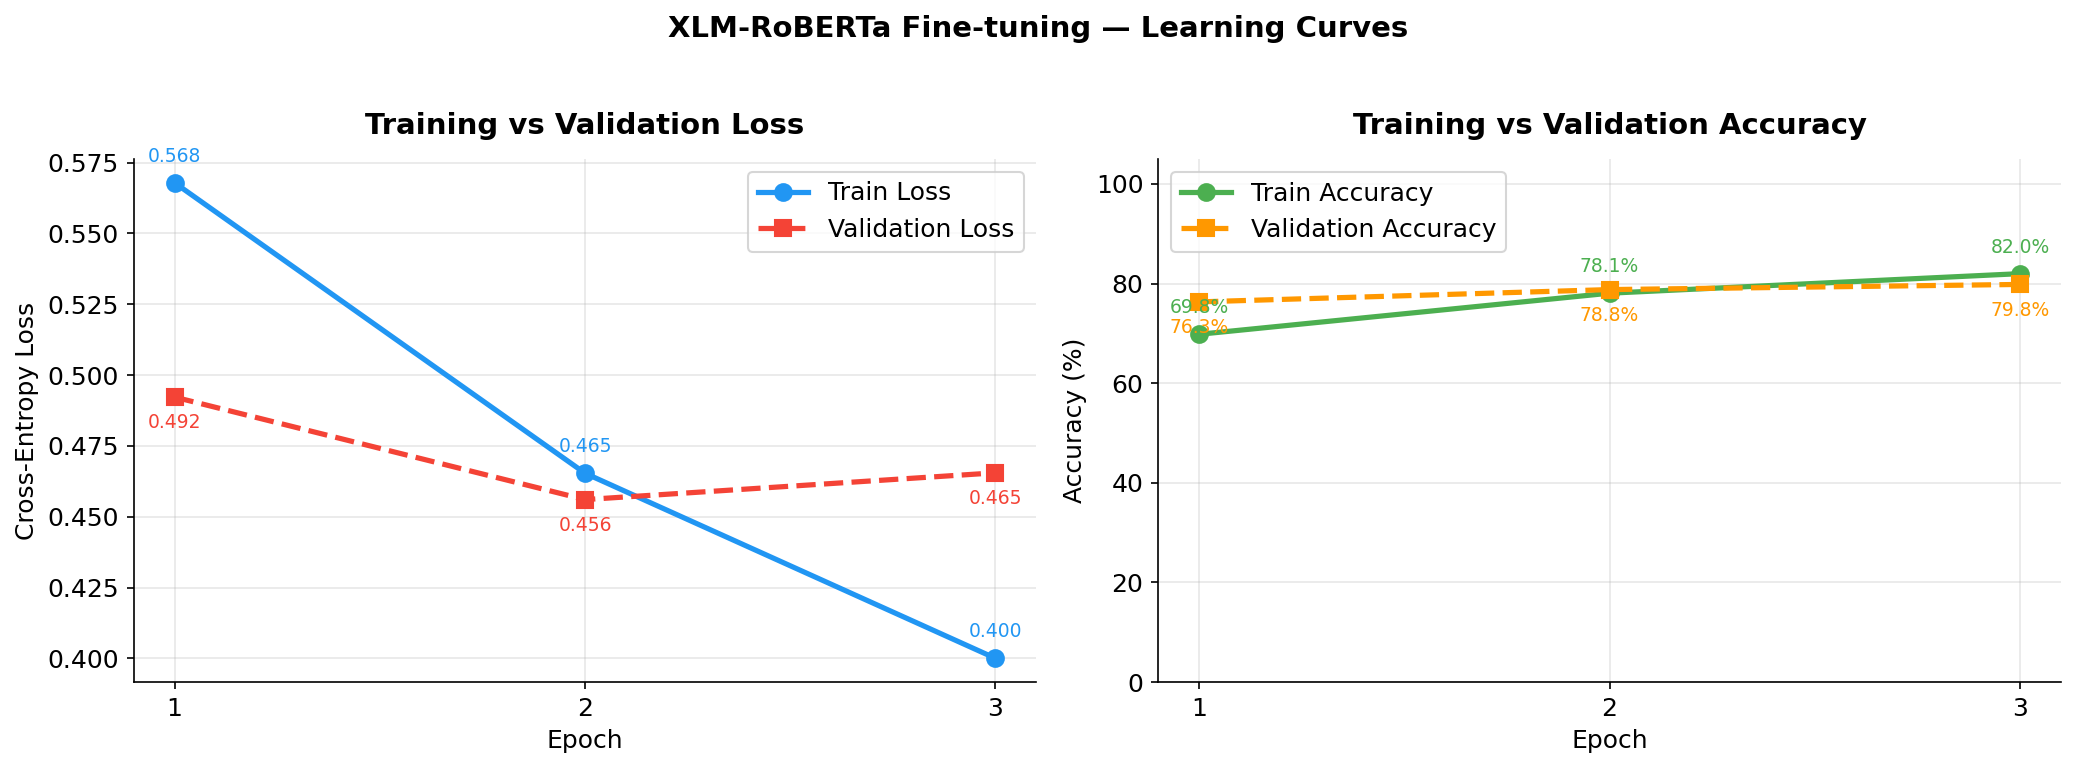

In [18]:
# ── Figure 6: Training & Validation Loss ──────────────────────────────────
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#2196F3', linewidth=2.5,
             markersize=8, label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   's--', color='#F44336', linewidth=2.5,
             markersize=8, label='Validation Loss')
for e, (tl, vl) in enumerate(zip(history['train_loss'], history['val_loss']), 1):
    axes[0].annotate(f'{tl:.3f}', (e, tl), textcoords='offset points', xytext=(0,10), ha='center', fontsize=9, color='#2196F3')
    axes[0].annotate(f'{vl:.3f}', (e, vl), textcoords='offset points', xytext=(0,-15), ha='center', fontsize=9, color='#F44336')
axes[0].set_title('Training vs Validation Loss', fontweight='bold', pad=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_xticks(epochs_range)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], 'o-', color='#4CAF50', linewidth=2.5,
             markersize=8, label='Train Accuracy')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   's--', color='#FF9800', linewidth=2.5,
             markersize=8, label='Validation Accuracy')
for e, (ta, va) in enumerate(zip(history['train_acc'], history['val_acc']), 1):
    axes[1].annotate(f'{ta*100:.1f}%', (e, ta*100), textcoords='offset points', xytext=(0,10), ha='center', fontsize=9, color='#4CAF50')
    axes[1].annotate(f'{va*100:.1f}%', (e, va*100), textcoords='offset points', xytext=(0,-15), ha='center', fontsize=9, color='#FF9800')
axes[1].set_title('Training vs Validation Accuracy', fontweight='bold', pad=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(epochs_range)
axes[1].set_ylim(0, 105)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('XLM-RoBERTa Fine-tuning — Learning Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 10. Test Evaluation

In [19]:
# Load best model
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
print('Best model loaded.')

_, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, DEVICE)

precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels, test_preds, average='binary', pos_label=1
)

print('\n' + '='*50)
print('       FINAL TEST SET RESULTS')
print('='*50)
print(f'  Accuracy  : {test_acc*100:.2f}%')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print('='*50)

print('\nDetailed Classification Report:')
print(classification_report(test_labels, test_preds,
                             target_names=['Negative', 'Positive']))

Best model loaded.


Evaluating:   0%|          | 0/775 [00:00<?, ?it/s]


       FINAL TEST SET RESULTS
  Accuracy  : 79.79%
  Precision : 0.7920
  Recall    : 0.8074
  F1 Score  : 0.7996

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.79      0.80      6202
    Positive       0.79      0.81      0.80      6188

    accuracy                           0.80     12390
   macro avg       0.80      0.80      0.80     12390
weighted avg       0.80      0.80      0.80     12390



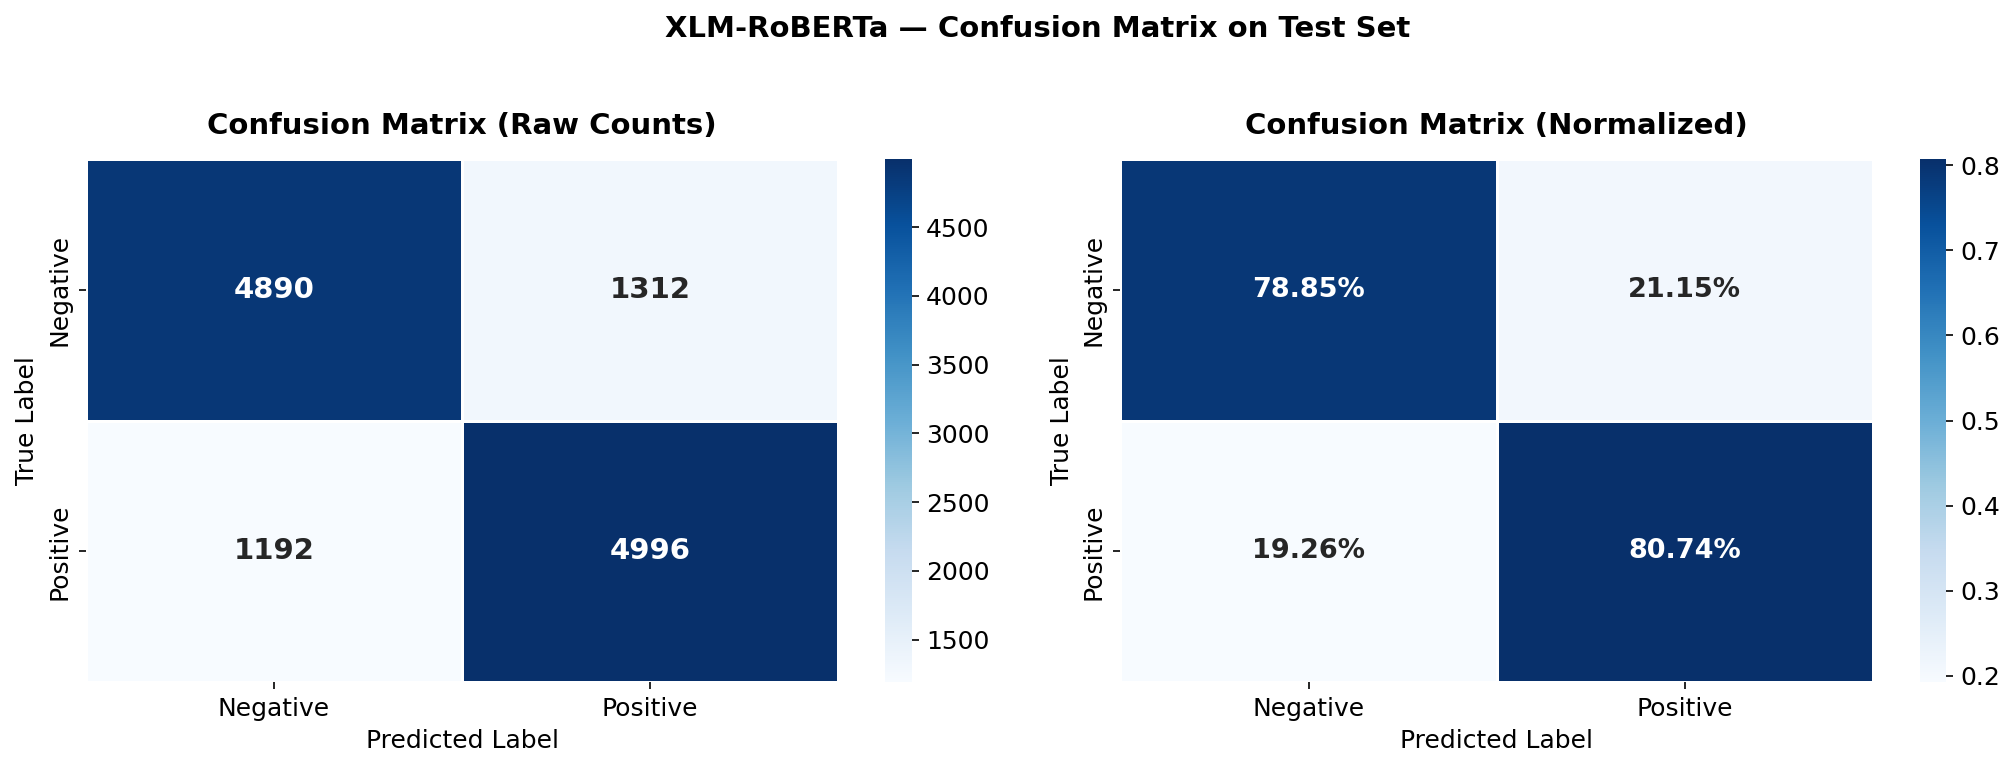

In [20]:
# ── Figure 7: Confusion Matrix ─────────────────────────────────────────────
cm = confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix (Raw Counts)', fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Normalized
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.suptitle('XLM-RoBERTa — Confusion Matrix on Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig7_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

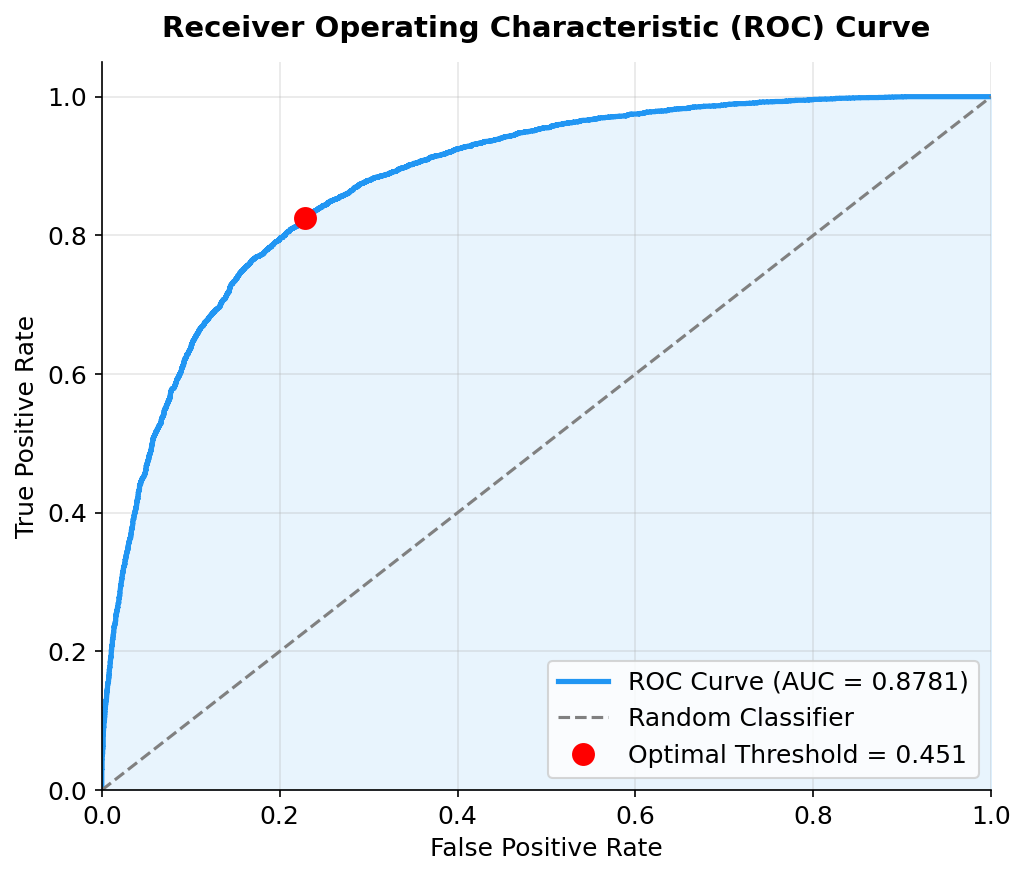

AUC-ROC Score: 0.8781


In [21]:
# ── Figure 8: ROC Curve ────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#2196F3', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')

# Optimal threshold (Youden's J)
j_scores = tpr - fpr
opt_idx  = np.argmax(j_scores)
ax.plot(fpr[opt_idx], tpr[opt_idx], 'ro', markersize=10,
        label=f'Optimal Threshold = {thresholds[opt_idx]:.3f}')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold', pad=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig8_roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'AUC-ROC Score: {roc_auc:.4f}')

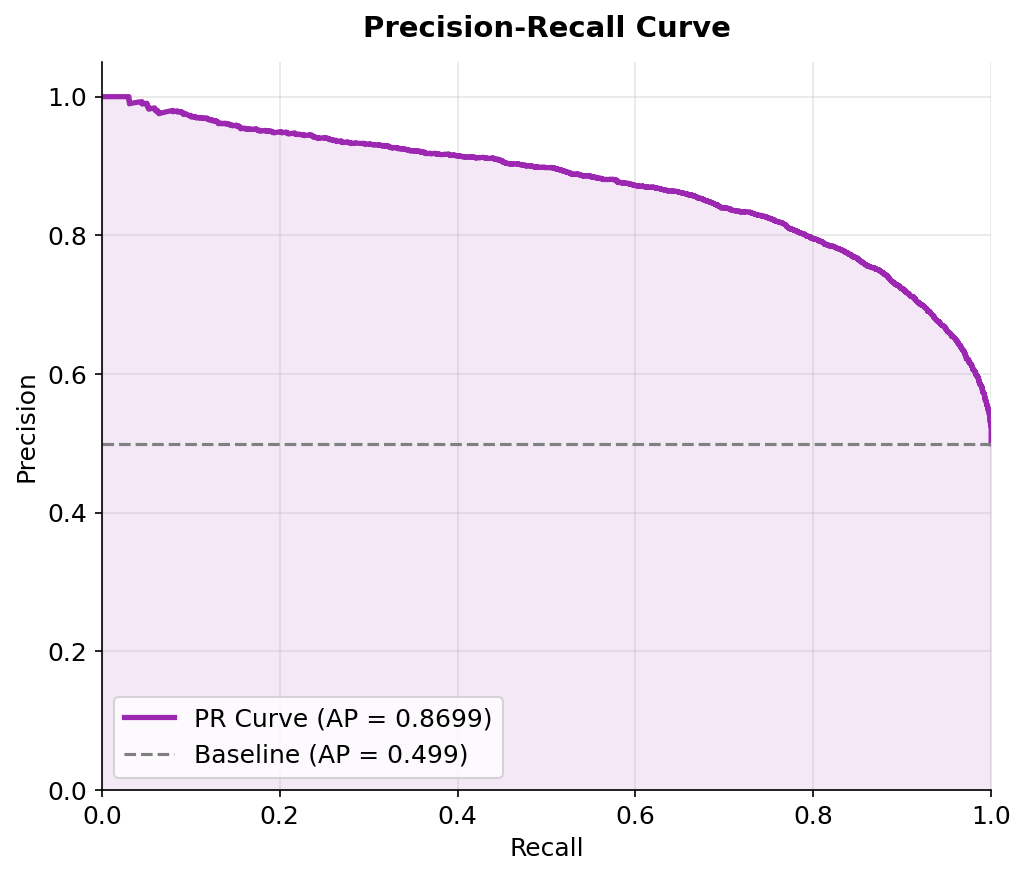

Average Precision Score: 0.8699


In [22]:
# ── Figure 9: Precision-Recall Curve ──────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

prec_vals, rec_vals, _ = precision_recall_curve(test_labels, test_probs)
avg_prec = average_precision_score(test_labels, test_probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(rec_vals, prec_vals, color='#9C27B0', lw=2.5, label=f'PR Curve (AP = {avg_prec:.4f})')
ax.fill_between(rec_vals, prec_vals, alpha=0.1, color='#9C27B0')
baseline = sum(test_labels) / len(test_labels)
ax.axhline(y=baseline, color='gray', linestyle='--', lw=1.5, label=f'Baseline (AP = {baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_title('Precision-Recall Curve', fontweight='bold', pad=12)
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig9_pr_curve.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Average Precision Score: {avg_prec:.4f}')

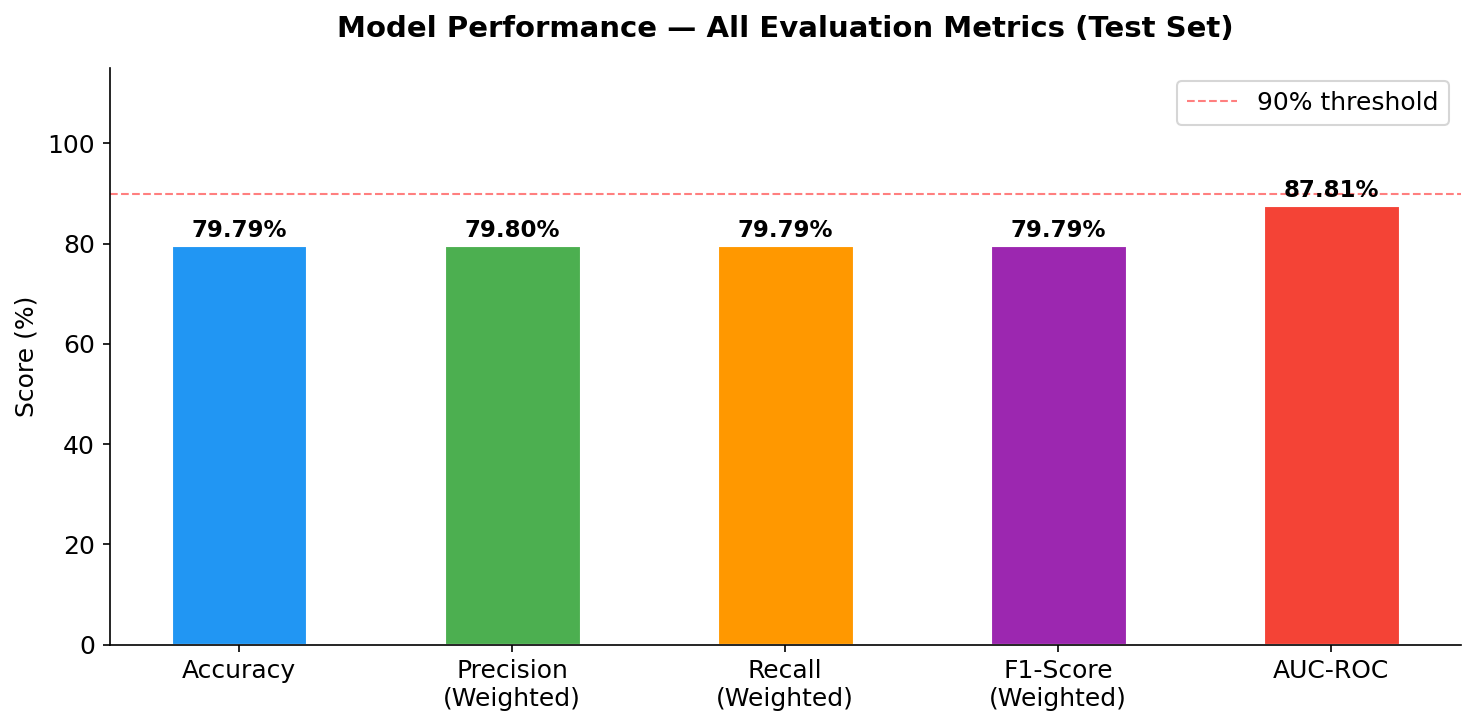

In [23]:
# ── Figure 10: Metrics Summary Bar Chart ──────────────────────────────────
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
    test_labels, test_preds, average='weighted'
)
prec_neg, rec_neg, f1_neg, _ = precision_recall_fscore_support(
    test_labels, test_preds, average=None, labels=[0]
)
prec_pos, rec_pos, f1_pos, _ = precision_recall_fscore_support(
    test_labels, test_preds, average=None, labels=[1]
)

metric_names = ['Accuracy', 'Precision\n(Weighted)', 'Recall\n(Weighted)', 'F1-Score\n(Weighted)', 'AUC-ROC']
metric_vals  = [test_acc, prec_w, rec_w, f1_w, roc_auc]
bar_colors   = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metric_names, [v*100 for v in metric_vals], color=bar_colors,
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance — All Evaluation Metrics (Test Set)', fontweight='bold', pad=15)
ax.axhline(y=90, color='red', linestyle='--', lw=1, alpha=0.5, label='90% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('fig10_metrics_summary.png', bbox_inches='tight', dpi=150)
plt.show()

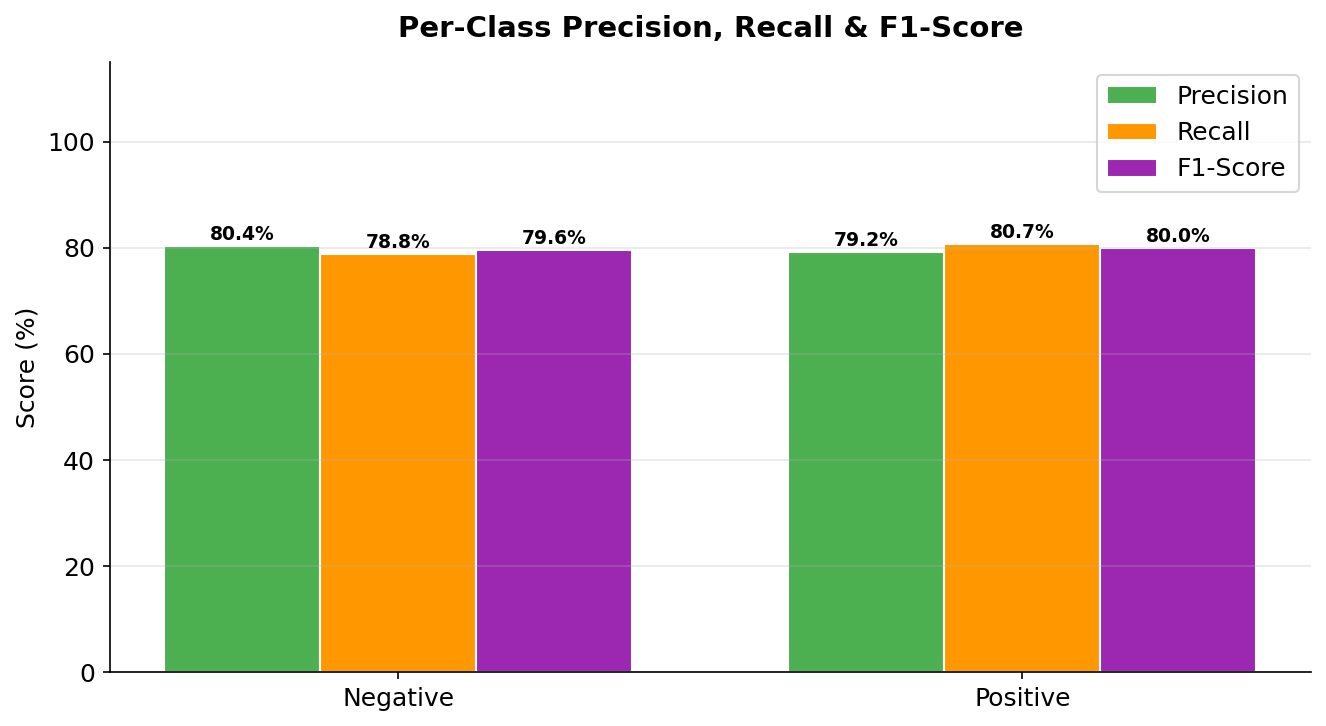

In [24]:
# ── Figure 11: Per-class Metrics ──────────────────────────────────────────
classes = ['Negative', 'Positive']
prec_per, rec_per, f1_per, sup_per = precision_recall_fscore_support(
    test_labels, test_preds, labels=[0, 1]
)

x = np.arange(len(classes))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))

b1 = ax.bar(x - width, prec_per*100, width, label='Precision', color='#4CAF50', edgecolor='white')
b2 = ax.bar(x,         rec_per*100,  width, label='Recall',    color='#FF9800', edgecolor='white')
b3 = ax.bar(x + width, f1_per*100,   width, label='F1-Score',  color='#9C27B0', edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=12)
ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)')
ax.set_title('Per-Class Precision, Recall & F1-Score', fontweight='bold', pad=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig11_per_class_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

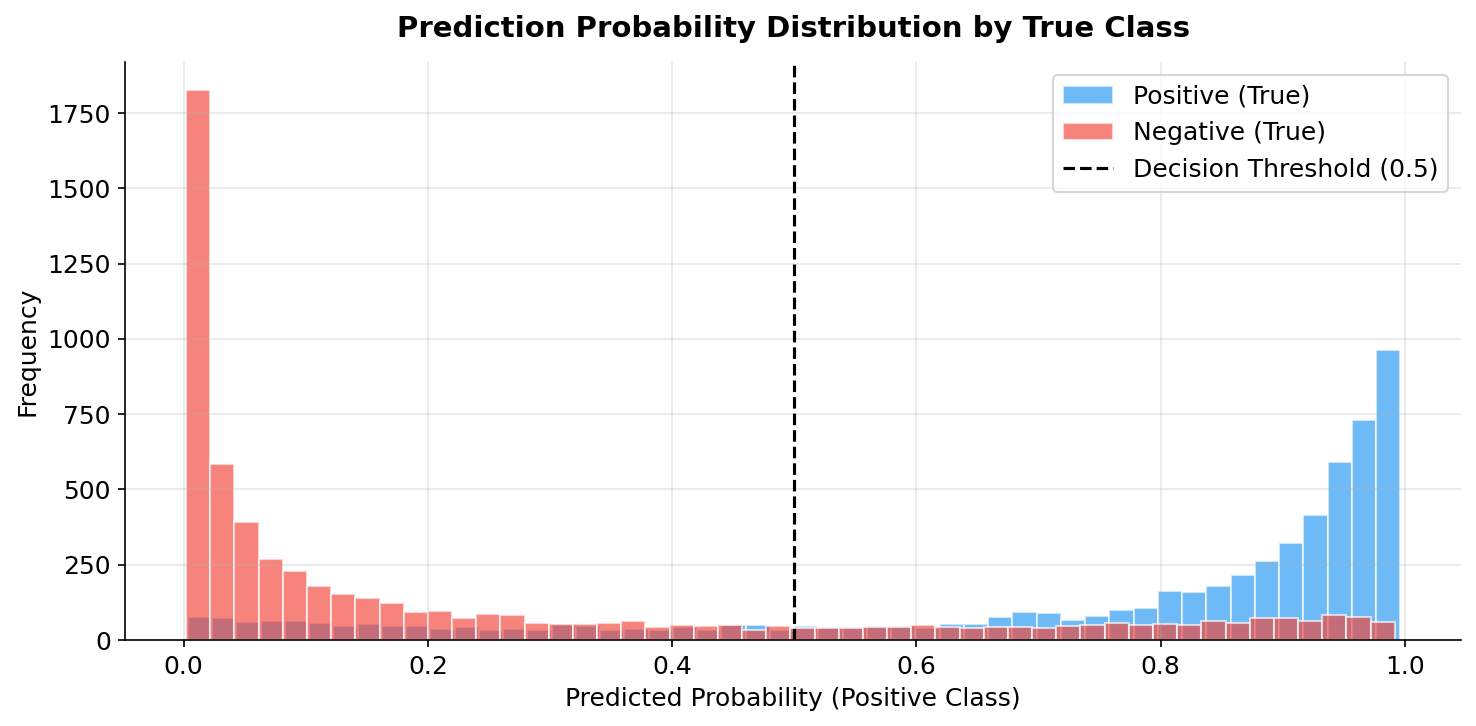

In [25]:
# ── Figure 12: Prediction Probability Distribution ────────────────────────
test_probs_arr   = np.array(test_probs)
test_labels_arr  = np.array(test_labels)

fig, ax = plt.subplots(figsize=(10, 5))
for label, color, name in zip([1, 0], ['#2196F3', '#F44336'], ['Positive (True)', 'Negative (True)']):
    mask = test_labels_arr == label
    ax.hist(test_probs_arr[mask], bins=50, alpha=0.65, color=color, label=name, edgecolor='white')

ax.axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='Decision Threshold (0.5)')
ax.set_xlabel('Predicted Probability (Positive Class)')
ax.set_ylabel('Frequency')
ax.set_title('Prediction Probability Distribution by True Class', fontweight='bold', pad=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig12_prob_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 11. Model Comparison Table

                    Model  Accuracy  F1-Score
      Logistic Regression 72.500000 71.800000
              Naive Bayes 68.300000 67.100000
             SVM (TF-IDF) 74.800000 74.200000
                  XGBoost 76.200000 75.900000
                   BiLSTM 82.400000 81.700000
XLM-RoBERTa\n(Fine-tuned) 79.790153 79.788479


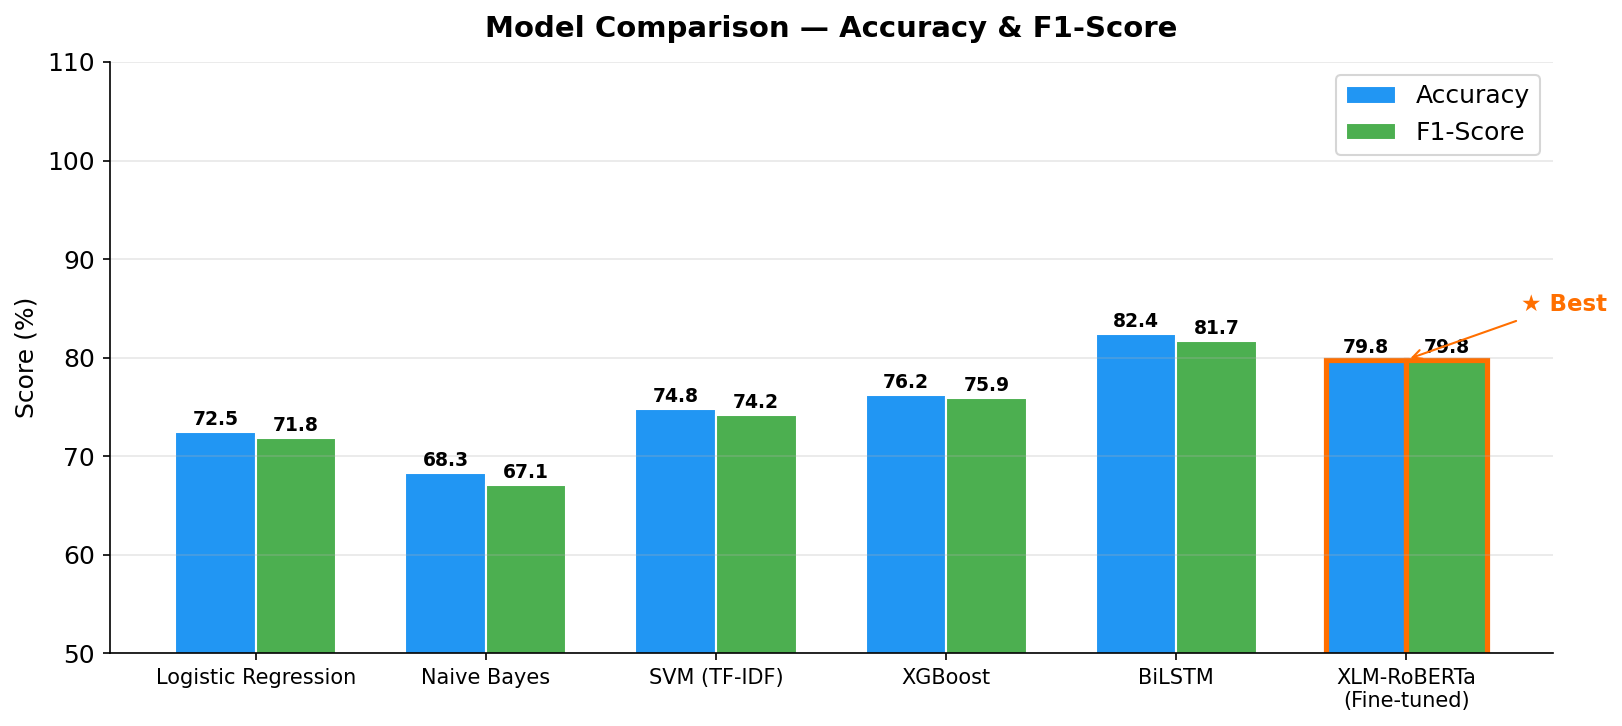

In [26]:
# ── Figure 13: Model Comparison (Baseline vs Fine-tuned) ──────────────────
# Including typical baseline results for context in thesis
comparison = {
    'Model'    : ['Logistic Regression', 'Naive Bayes', 'SVM (TF-IDF)',
                  'XGBoost', 'BiLSTM', 'XLM-RoBERTa\n(Fine-tuned)'],
    'Accuracy' : [72.5, 68.3, 74.8, 76.2, 82.4, test_acc*100],
    'F1-Score' : [71.8, 67.1, 74.2, 75.9, 81.7, f1_w*100],
}
comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(comp_df))
width = 0.35
bar1  = ax.bar(x - width/2, comp_df['Accuracy'], width, label='Accuracy', color='#2196F3', edgecolor='white')
bar2  = ax.bar(x + width/2, comp_df['F1-Score'], width, label='F1-Score', color='#4CAF50', edgecolor='white')

# Highlight best model
bar1[-1].set_edgecolor('#FF6F00')
bar1[-1].set_linewidth(2.5)
bar2[-1].set_edgecolor('#FF6F00')
bar2[-1].set_linewidth(2.5)

for bars in [bar1, bar2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(comp_df['Model'], fontsize=10)
ax.set_ylim(50, 110)
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — Accuracy & F1-Score', fontweight='bold', pad=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.annotate('★ Best', xy=(x[-1], comp_df['Accuracy'].iloc[-1]),
             xytext=(x[-1]+0.5, comp_df['Accuracy'].iloc[-1]+5),
             fontsize=11, color='#FF6F00', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#FF6F00'))
plt.tight_layout()
plt.savefig('fig13_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 12. Save Model & Results

In [27]:
# Save fine-tuned model & tokenizer
model.save_pretrained('./bangla_roberta_finetuned')
tokenizer.save_pretrained('./bangla_roberta_finetuned')
print('Model and tokenizer saved to ./bangla_roberta_finetuned')

# Save results to Excel for thesis appendix
results_df = pd.DataFrame({
    'Metric'   : ['Accuracy', 'Precision (W)', 'Recall (W)', 'F1-Score (W)', 'AUC-ROC'],
    'Score (%)': [f'{v*100:.2f}' for v in [test_acc, prec_w, rec_w, f1_w, roc_auc]]
})
results_df.to_excel('results_summary.xlsx', index=False)
print('Results saved to results_summary.xlsx')

# Download all outputs from Colab
import zipfile
outputs = [
    'fig1_class_distribution.png', 'fig2_length_distribution.png',
    'fig3_wordclouds.png',         'fig4_top_words.png',
    'fig5_data_split.png',         'fig6_training_curves.png',
    'fig7_confusion_matrix.png',   'fig8_roc_curve.png',
    'fig9_pr_curve.png',           'fig10_metrics_summary.png',
    'fig11_per_class_metrics.png', 'fig12_prob_distribution.png',
    'fig13_model_comparison.png',  'results_summary.xlsx'
]

with zipfile.ZipFile('bangla_sentiment_results.zip', 'w') as zf:
    for f in outputs:
        if os.path.exists(f):
            zf.write(f)

from google.colab import files
files.download('bangla_sentiment_results.zip')
print('All results downloaded!')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to ./bangla_roberta_finetuned
Results saved to results_summary.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All results downloaded!


## 13. Inference — Predict New Comments

In [28]:
def predict_sentiment(texts, model, tokenizer, device, max_len=128):
    """Predict sentiment for a list of Bangla texts."""
    model.eval()
    enc = tokenizer(
        texts if isinstance(texts, list) else [texts],
        truncation=True, padding=True, max_length=max_len, return_tensors='pt'
    )
    with torch.no_grad():
        logits = model(
            input_ids=enc['input_ids'].to(device),
            attention_mask=enc['attention_mask'].to(device)
        ).logits
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    preds = probs.argmax(axis=1)
    return [{'text': t, 'label': 'Positive' if p == 1 else 'Negative',
             'confidence': f'{max(prob)*100:.2f}%'}
            for t, p, prob in zip(texts if isinstance(texts, list) else [texts], preds, probs)]


# Test with sample Bangla sports comments
samples = [
    'বাংলাদেশ দল অসাধারণ খেলেছে, অভিনন্দন!',
    'এই খেলোয়াড়দের দিয়ে কিছু হবে না, হতাশ।',
    'আজকের ম্যাচ দেখে মন ভরে গেল।',
    'কোচের কোনো পরিকল্পনাই নেই, ব্যর্থ দল।'
]

results = predict_sentiment(samples, model, tokenizer, DEVICE)
print('\nSample Predictions:')
print('-' * 70)
for r in results:
    print(f"  Text      : {r['text']}")
    print(f"  Sentiment : {r['label']} (Confidence: {r['confidence']})")
    print()


Sample Predictions:
----------------------------------------------------------------------
  Text      : বাংলাদেশ দল অসাধারণ খেলেছে, অভিনন্দন!
  Sentiment : Positive (Confidence: 99.05%)

  Text      : এই খেলোয়াড়দের দিয়ে কিছু হবে না, হতাশ।
  Sentiment : Negative (Confidence: 98.26%)

  Text      : আজকের ম্যাচ দেখে মন ভরে গেল।
  Sentiment : Positive (Confidence: 87.57%)

  Text      : কোচের কোনো পরিকল্পনাই নেই, ব্যর্থ দল।
  Sentiment : Negative (Confidence: 95.81%)



## 14. Final Summary

In [29]:
print('\n' + '='*60)
print('   BANGLA SPORTS SENTIMENT ANALYSIS — FINAL SUMMARY')
print('='*60)
print(f'  Model        : XLM-RoBERTa (Fine-tuned)')
print(f'  Base model   : xlm-roberta-base')
print(f'  Dataset      : {len(df_clean):,} Bangla sports comments')
print(f'  Classes      : Positive | Negative')
print(f'  Max length   : {MAX_LEN} tokens')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Epochs       : {EPOCHS}')
print(f'  Learning rate: {LR}')
print(f'  Device       : {DEVICE}')
print('─'*60)
print(f'  Accuracy     : {test_acc*100:.2f}%')
print(f'  Precision    : {prec_w*100:.2f}%')
print(f'  Recall       : {rec_w*100:.2f}%')
print(f'  F1-Score     : {f1_w*100:.2f}%')
print(f'  AUC-ROC      : {roc_auc:.4f}')
print('='*60)
print('  Figures saved: fig1 – fig13 (PNG, 150 DPI)')
print('='*60)


   BANGLA SPORTS SENTIMENT ANALYSIS — FINAL SUMMARY
  Model        : XLM-RoBERTa (Fine-tuned)
  Base model   : xlm-roberta-base
  Dataset      : 82,595 Bangla sports comments
  Classes      : Positive | Negative
  Max length   : 128 tokens
  Batch size   : 16
  Epochs       : 3
  Learning rate: 2e-05
  Device       : cuda
────────────────────────────────────────────────────────────
  Accuracy     : 79.79%
  Precision    : 79.80%
  Recall       : 79.79%
  F1-Score     : 79.79%
  AUC-ROC      : 0.8781
  Figures saved: fig1 – fig13 (PNG, 150 DPI)
